STEP 1: DATASET OVERVIEW
Total rows    : 5110
Total columns : 12

Columns:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Target (stroke) distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

STEP 2: DATA PREPROCESSING
Dropped 'id' column
Removed 1 row with gender='Other'
Filled 201 missing BMI values with median (28.1)
Label encoded columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

STEP 3: HANDLE CLASS IMBALANCE
Before balancing: {0: 4860, 1: 249}
After  balancing: {0: 4860, 1: 4860}

STEP 4: SPLIT D

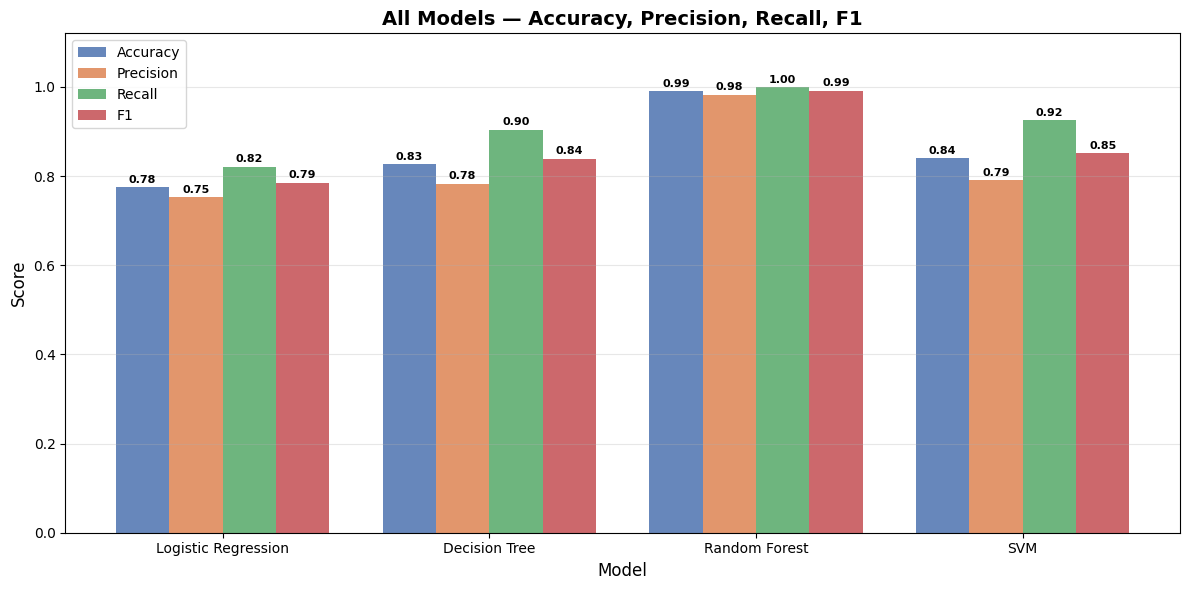

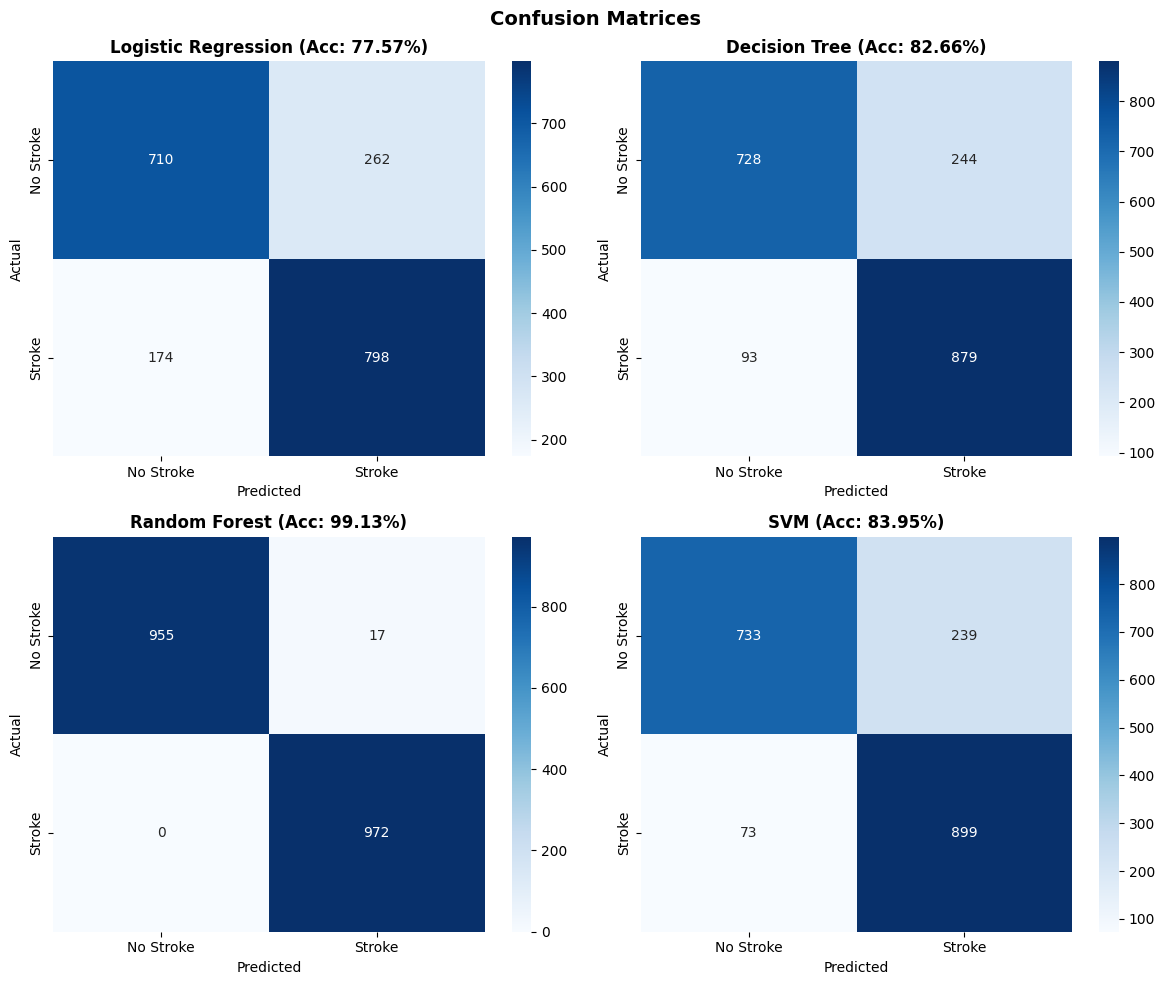

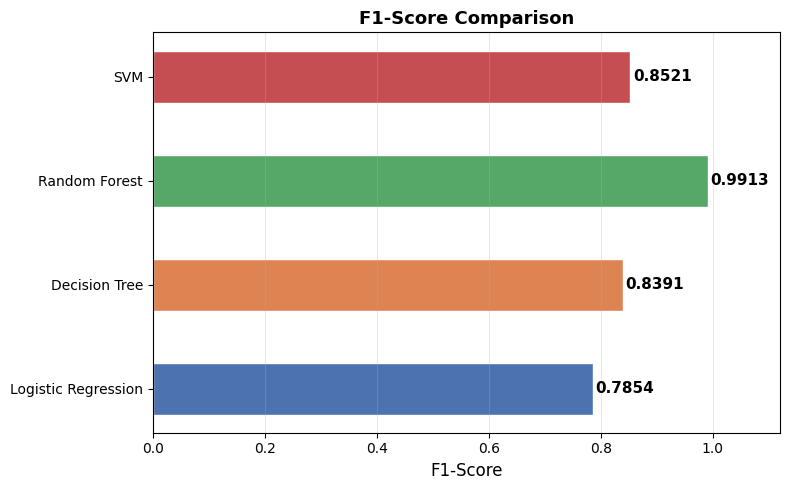


Done! All plots saved.


In [ ]:
# =============================================================
#   ML LAB REPORT — Healthcare Stroke Dataset
#   4 Supervised Models: LR | Decision Tree | Random Forest | SVM
#   Author: Rakib
# =============================================================

# ── IMPORTS ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# STEP 1 — LOAD DATA
# =============================================================
df = pd.read_csv('/content/drive/MyDrive/Classroom/CSE 422 (AI Sessional)/healthcare-dataset-stroke-data.csv')

print("=" * 60)
print("STEP 1: DATASET OVERVIEW")
print("=" * 60)
print(f"Total rows    : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nTarget (stroke) distribution:")
print(df['stroke'].value_counts())
# Insight: 4861 no-stroke vs 249 stroke → very imbalanced!
print(f"\nMissing values:\n{df.isnull().sum()}")

# =============================================================
# STEP 2 — DATA PREPROCESSING
# =============================================================
print("\n" + "=" * 60)
print("STEP 2: DATA PREPROCESSING")
print("=" * 60)

# 2a. Drop 'id' — it's just an identifier, not a feature
df.drop('id', axis=1, inplace=True)
print("Dropped 'id' column")

# 2b. Remove the 1 row where gender = 'Other' (too rare to be useful)
df = df[df['gender'] != 'Other']
print("Removed 1 row with gender='Other'")

# 2c. Fill missing BMI values with the median
#     (Why median and not mean? Because BMI can have outliers — median is safer)
median_bmi = df['bmi'].median()
df['bmi'].fillna(median_bmi, inplace=True)
print(f"Filled {201} missing BMI values with median ({median_bmi:.1f})")

# 2d. Label Encode categorical columns (convert text → numbers)
#     ML models need numbers, not text!
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print(f"Label encoded columns: {cat_cols}")

# =============================================================
# STEP 3 — HANDLE CLASS IMBALANCE (Oversampling)
# =============================================================
print("\n" + "=" * 60)
print("STEP 3: HANDLE CLASS IMBALANCE")
print("=" * 60)

# Problem: only 249 stroke cases vs 4860 non-stroke cases
# If we train on this, the model will just predict "no stroke" always!
# Solution: Oversample the minority class (stroke=1) to match majority

df_majority  = df[df['stroke'] == 0]  # 4860 rows
df_minority  = df[df['stroke'] == 1]  # 249 rows

df_minority_upsampled = resample(df_minority,
                                  replace=True,           # sample with replacement
                                  n_samples=len(df_majority),  # match majority count
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
print(f"Before balancing: {df['stroke'].value_counts().to_dict()}")
print(f"After  balancing: {df_balanced['stroke'].value_counts().to_dict()}")

# =============================================================
# STEP 4 — FEATURE/TARGET SPLIT & TRAIN-TEST SPLIT
# =============================================================
print("\n" + "=" * 60)
print("STEP 4: SPLIT DATA")
print("=" * 60)

X = df_balanced.drop('stroke', axis=1)   # Features (input)
y = df_balanced['stroke']                  # Target  (output)

# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling — StandardScaler makes all features same scale (mean=0, std=1)
# Why? SVM and Logistic Regression are sensitive to feature scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_sc  = scaler.transform(X_test)       # only transform test (no fit!)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# =============================================================
# STEP 5 — TRAIN 4 SUPERVISED MODELS
# =============================================================
print("\n" + "=" * 60)
print("STEP 5: TRAINING 4 MODELS")
print("=" * 60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)        # Train
    y_pred = model.predict(X_test_sc)     # Predict

    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'y_pred':    y_pred
    }

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Stroke', 'Stroke']))

# =============================================================
# STEP 6 — COMPARISON TABLE
# =============================================================
print("\n" + "=" * 60)
print("STEP 6: MODEL COMPARISON TABLE")
print("=" * 60)
print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─" * 65)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")

# =============================================================
# STEP 7 — VISUALIZATIONS
# =============================================================
model_names = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# --- Plot 1: Grouped Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.2

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(),
                  color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — Accuracy, Precision, Recall, F1', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_comparison.png', dpi=150)
plt.show()

# --- Plot 2: Confusion Matrices ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for idx, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    axes[idx].set_title(f'{name} (Acc: {r["accuracy"]:.2%})', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_confusion.png', dpi=150)
plt.show()

# --- Plot 3: F1 Horizontal Bar ---
fig, ax = plt.subplots(figsize=(8, 5))
f1_vals = [results[m]['f1'] for m in model_names]
bars = ax.barh(model_names, f1_vals, color=colors, edgecolor='white', height=0.5)
for bar, v in zip(bars, f1_vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.12)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_f1.png', dpi=150)
plt.show()

print("\nDone! All plots saved.")
